> **本ノートブックについて**
> これは書籍『対称性をめぐって —圏論的対称性への誘い—』（山崎雅人 著）に付随する Jupyter ノートブックです．
> 付録B「厳密対角化の数値計算」で説明している計算の全体と，本文の図（第6章・付録B）を作るコードが含まれています．
> 最新版・関連情報はサポートページ https://github.com/masahitoyamazaki/KWbook を参照してください．

# 横磁場イジング模型の厳密対角化（付録B）

$$H_{\rm Ising}(g) = -g^{-1}\sum_{j=1}^L Z_jZ_{j+1} - g\sum_{j=1}^L X_j$$

このノートブックでは
1. $\mathbb{Z}_2$ 対称性 $\eta=\prod_j X_j$ のセクターごとの厳密対角化
2. クラマース＝ワニエ（KW）双対性 $g\leftrightarrow g^{-1}$ の数値的確認（ねじれた境界条件を含む）
3. 付録Cのジョルダン＝ウィグナー変換による厳密解との比較
4. 低エネルギースペクトルとギャップの図（本文の図）
5. 臨界点 $g=1$ でのギャップの有限サイズスケーリング
6. KW欠陥（第8.2節）の位置によらないスペクトルの確認

を行います．必要なものは `numpy`, `scipy`, `matplotlib` だけです．

In [1]:
import os
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

FIGDIR = "figures"   # 図の出力先（このノートブックと同じ場所に作られる）
os.makedirs(FIGDIR, exist_ok=True)

## 1. セクターごとのハミルトニアン

$\eta=\prod_j X_j$ は計算基底で対角ではないので，全サイトにアダマール変換をかけて $X\leftrightarrow Z$ を入れ替えた基底で計算します．
この基底では
$$H = -g^{-1}\sum_j X_jX_{j+1} - g\sum_j Z_j,\qquad \eta=\prod_j Z_j$$
となり，$\eta$ の値は $|s_1\cdots s_L\rangle$ の $1$ の個数の偶奇で決まります．
スピン配位は，$s_j$ を第 $j$ ビットとする整数で表します．

引数 `twist=1` とすると，ねじれた境界条件 $Z_{L+1}=-Z_1$（第7.3節）を課します．この基底では境界の項 $X_LX_1$ の符号が反転します．

In [2]:
def hamiltonian_sector(L, g, eta, twist=0):
    """eta=+1/-1 のセクターに制限した H_Ising(g) を疎行列で返す．"""
    states = np.arange(2 ** L)
    parity = np.array([(-1) ** bin(n).count("1") for n in states])
    sector = states[parity == eta]
    index = {n: k for k, n in enumerate(sector)}
    rows, cols, vals = [], [], []
    for k, n in enumerate(sector):
        diag = -g * sum((-1) ** ((n >> j) & 1) for j in range(L))      # -g sum Z_j
        rows.append(k); cols.append(k); vals.append(diag)
        for j in range(L):                                              # -g^{-1} X_j X_{j+1}
            m = n ^ (1 << j) ^ (1 << ((j + 1) % L))
            sign = -1 if (twist and j == L - 1) else 1
            rows.append(index[m]); cols.append(k); vals.append(-sign / g)
    return sp.csr_matrix((vals, (rows, cols)), shape=(len(sector),) * 2)

def levels(L, g, eta, k=4, twist=0):
    H = hamiltonian_sector(L, g, eta, twist)
    if H.shape[0] <= 64:
        return np.sort(np.linalg.eigvalsh(H.toarray()))[:k]
    return np.sort(spla.eigsh(H, k=k, which="SA", return_eigenvectors=False))

## 2. KW双対性の確認

第7.3節によると，KW変換 $\mathsf{D}$ は（元の境界条件のねじれ $t$，$\eta$ の固有値）を（双対側のねじれ $\hat t$，$\hat\eta$ の固有値）に次のように対応させます：
$$(t=0,\ \eta=+1)\ \leftrightarrow\ (\hat t=0,\ \hat\eta=+1),\qquad (t=0,\ \eta=-1)\ \leftrightarrow\ (\hat t=1,\ \hat\eta=+1).$$
したがって，$H_{\rm Ising}(g)$ と $H_{\rm Ising}(g^{-1})$ の対応するセクターの固有値は一致するはずです．

In [3]:
L = 10
for g in [0.5, 0.8, 1.5]:
    even = np.max(np.abs(levels(L, g, +1, 6) - levels(L, 1 / g, +1, 6)))
    odd  = np.max(np.abs(levels(L, g, -1, 6) - levels(L, 1 / g, +1, 6, twist=1)))
    naive = np.max(np.abs(levels(L, g, -1, 6) - levels(L, 1 / g, -1, 6)))
    print(f"g={g}: (eta=+1)<->(eta=+1): {even:.1e},  (eta=-1)<->(twisted, eta=+1): {odd:.1e},"
          f"  (eta=-1)<->(eta=-1) [一致しないはず]: {naive:.1e}")

g=0.5: (eta=+1)<->(eta=+1): 3.9e-14,  (eta=-1)<->(twisted, eta=+1): 8.0e-14,  (eta=-1)<->(eta=-1) [一致しないはず]: 3.0e+00
g=0.8: (eta=+1)<->(eta=+1): 3.7e-14,  (eta=-1)<->(twisted, eta=+1): 2.8e-14,  (eta=-1)<->(eta=-1) [一致しないはず]: 9.0e-01
g=1.5: (eta=+1)<->(eta=+1): 5.0e-14,  (eta=-1)<->(twisted, eta=+1): 3.2e-14,  (eta=-1)<->(eta=-1) [一致しないはず]: 1.7e+00


## 3. ジョルダン＝ウィグナー変換による厳密解との比較

付録Cによると，$\eta=+1$ セクターの基底エネルギーは，反周期的境界条件の運動量 $k=\frac{2\pi}{L}(n+\frac12)$ について
$$E_{\rm GS}=-\frac12\sum_k\epsilon_k,\qquad \epsilon_k=2\sqrt{g^2+g^{-2}-2\cos k}$$
で与えられます．

In [4]:
def exact_ground_energy(L, g):
    ks = 2 * np.pi * (np.arange(L) + 0.5) / L
    return -0.5 * np.sum(2 * np.sqrt(g ** 2 + g ** -2 - 2 * np.cos(ks)))

for L in [4, 8, 12]:
    for g in [0.5, 1.0, 2.0]:
        print(f"L={L:2d} g={g}:  ED={levels(L, g, +1, 1)[0]:.10f}  exact={exact_ground_energy(L, g):.10f}")

L= 4 g=0.5:  ED=-8.1278803561  exact=-8.1278803561
L= 4 g=1.0:  ED=-5.2262518595  exact=-5.2262518595
L= 4 g=2.0:  ED=-8.1278803561  exact=-8.1278803561
L= 8 g=0.5:  ED=-16.2509984295  exact=-16.2509984295
L= 8 g=1.0:  ED=-10.2516617910  exact=-10.2516617910
L= 8 g=2.0:  ED=-16.2509984295  exact=-16.2509984295
L=12 g=0.5:  ED=-24.3764883280  exact=-24.3764883280


L=12 g=1.0:  ED=-15.3225951511  exact=-15.3225951511
L=12 g=2.0:  ED=-24.3764883280  exact=-24.3764883280


## 4. 低エネルギースペクトルとギャップ（本文の図）

- `ed_spectrum.pdf`：$L=12$ の低エネルギー準位（基底エネルギーからの差）．$g<1$ では $\eta=\pm1$ の最低準位がほぼ縮退し，$g>1$ では基底状態は $\eta=+1$ の一つだけになります．
- `ed_gap.pdf`：$\eta=+1$ セクター内のギャップ．$L\to\infty$ では付録Cの $4|g-g^{-1}|$ に近づき，$g=1$ で閉じます．

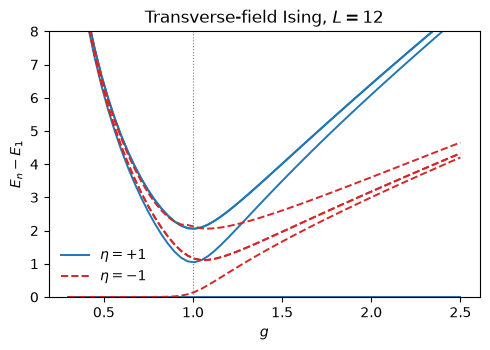

In [5]:
L = 12
gs = np.linspace(0.3, 2.5, 60)
plus = np.array([levels(L, g, +1, 4) for g in gs])
minus = np.array([levels(L, g, -1, 4) for g in gs])
e0 = np.minimum(plus[:, 0], minus[:, 0])
fig, ax = plt.subplots(figsize=(5, 3.6))
for n in range(4):
    ax.plot(gs, plus[:, n] - e0, "-", color="C0", lw=1.4, label=r"$\eta=+1$" if n == 0 else None)
    ax.plot(gs, minus[:, n] - e0, "--", color="C3", lw=1.4, label=r"$\eta=-1$" if n == 0 else None)
ax.axvline(1.0, color="gray", lw=0.8, ls=":")
ax.set(xlabel=r"$g$", ylabel=r"$E_n - E_1$", ylim=(0, 8), title=rf"Transverse-field Ising, $L={L}$")
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "ed_spectrum.pdf")); plt.show()

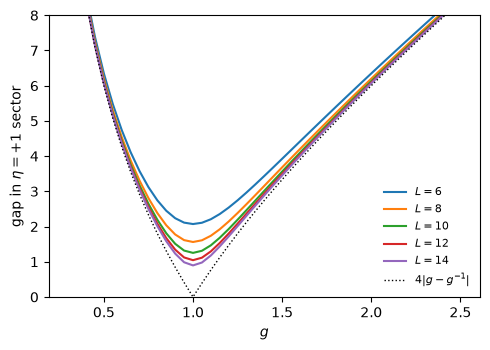

In [6]:
fig, ax = plt.subplots(figsize=(5, 3.6))
gs = np.linspace(0.3, 2.5, 45)
for L in [6, 8, 10, 12, 14]:
    ax.plot(gs, [np.diff(levels(L, g, +1, 2))[0] for g in gs], label=rf"$L={L}$")
ax.plot(gs, 4 * np.abs(gs - 1 / gs), "k:", lw=1, label=r"$4|g-g^{-1}|$")
ax.set(xlabel=r"$g$", ylabel=r"gap in $\eta=+1$ sector", ylim=(0, 8))
ax.legend(frameon=False, fontsize=8); fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "ed_gap.pdf")); plt.show()

## 5. 臨界点でのギャップの閉じ方

$g=1$ では $\epsilon_k=4|\sin(k/2)|$ なので，$\eta=+1$ セクターの最低励起（運動量 $\pm\pi/L$ のフェルミオン2個）のエネルギーは
$$\Delta(L)=8\sin\frac{\pi}{2L}\ \xrightarrow{L\to\infty}\ \frac{4\pi}{L}$$
となり，ギャップは $1/L$ で閉じます．これは臨界点の理論が共形場の理論であることの表れです（エネルギー演算子のスケーリング次元 $1$ と光速 $v=2$ から $\Delta = 2\pi v\cdot 1/L$）．
一方 $g\neq1$ では，ギャップは $L\to\infty$ で有限の値に収束します．

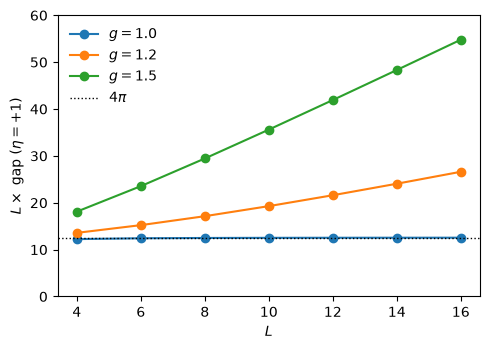

L*gap at g=1: [12.2459, 12.4233, 12.4858, 12.5148, 12.5305, 12.54, 12.5462]


In [7]:
Ls = np.arange(4, 17, 2)
fig, ax = plt.subplots(figsize=(5, 3.6))
for g, c in [(1.0, "C0"), (1.2, "C1"), (1.5, "C2")]:
    gaps = np.array([np.diff(levels(L, g, +1, 2))[0] for L in Ls])
    ax.plot(Ls, Ls * gaps, "o-", color=c, label=rf"$g={g}$")
ax.axhline(4 * np.pi, color="k", ls=":", lw=1, label=r"$4\pi$")
ax.set(xlabel=r"$L$", ylabel=r"$L\times$ gap ($\eta=+1$)", ylim=(0, 60))
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "ed_scaling.pdf")); plt.show()
print("L*gap at g=1:", [round(float(L * np.diff(levels(L, 1.0, +1, 2))[0]), 4) for L in Ls])

## 6. KW欠陥のスペクトル（第8.2節「部分的なゲージ化」の発展問題）

$g=1$ の周期的な鎖で，$-Z_kZ_{k+1}-X_{k+1}$ を $-Z_kX_{k+1}$ に置き換えたハミルトニアン（KW欠陥）を考えます．
欠陥の位置 $k$ を変えてもスペクトルが変わらないことを確かめます．ここでは素直に計算基底で $2^L\times2^L$ 行列を作ります．

In [8]:
def op(L, d):
    I2 = np.eye(2); mats = [d.get(i, I2) for i in range(L)]
    out = mats[0]
    for M in mats[1:]:
        out = np.kron(out, M)
    return out

X = np.array([[0., 1.], [1., 0.]]); Z = np.diag([1., -1.])
def defect_hamiltonian(L, k):
    H = sum(-op(L, {j: Z, (j + 1) % L: Z}) - op(L, {j: X}) for j in range(L))
    return H + op(L, {k: Z, (k + 1) % L: Z}) + op(L, {(k + 1) % L: X}) - op(L, {k: Z, (k + 1) % L: X})

L = 8
spectra = [np.linalg.eigvalsh(defect_hamiltonian(L, k)) for k in range(L)]
print("欠陥の位置によらずスペクトルが一致:", all(np.allclose(spectra[0], s) for s in spectra))
print("最低エネルギー:", np.round(spectra[0][:5], 6))

欠陥の位置によらずスペクトルが一致: True
最低エネルギー: [-9.514364 -9.514364 -8.682718 -8.682718 -7.887418]


## 7. 第6章の図：ギャップ $\Delta=E_2-E_1$ の $g$ 依存性

第6章の定義どおり，全スペクトルの基底エネルギー $E_1$ と第一励起エネルギー $E_2$ の差 $\Delta$ を描きます（`ising_gap.pdf`）．
$g<1$ では二つの基底状態がほぼ縮退しているので，$L$ を大きくすると $\Delta$ は指数関数的に $0$ に近づきます．
$g>1$ では $\Delta$ は $L\to\infty$ で $2(g-g^{-1})$ に近づきます．

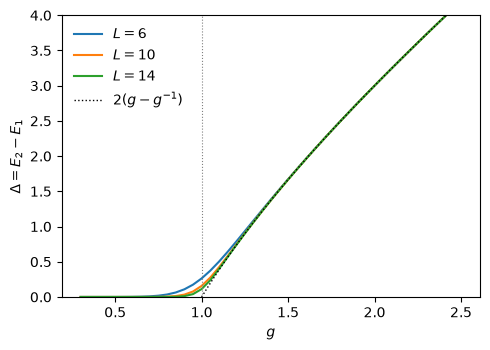

In [9]:
fig, ax = plt.subplots(figsize=(5, 3.6))
gs = np.linspace(0.3, 2.5, 45)
for L in [6, 10, 14]:
    gap = []
    for g in gs:
        e = np.sort(np.concatenate([levels(L, g, +1, 2), levels(L, g, -1, 2)]))
        gap.append(e[1] - e[0])
    ax.plot(gs, gap, label=rf"$L={L}$")
gg = np.linspace(1, 2.5, 50)
ax.plot(gg, 2 * (gg - 1 / gg), "k:", lw=1, label=r"$2(g-g^{-1})$")
ax.axvline(1.0, color="gray", lw=0.8, ls=":")
ax.set(xlabel=r"$g$", ylabel=r"$\Delta = E_2 - E_1$", ylim=(0, 4))
ax.legend(frameon=False); fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, "ising_gap.pdf")); plt.show()